## Bid vs Aggregate Markout (Per Round)

This notebook plots a scatter of winner bid in USD (x) vs aggregate markout (y) and overlays a simple linear regression line.

Input: `auction_resolved_with_markouts.csv` produced by the pipeline.


Pearson r = 0.1150, p-value = 0.000e+00


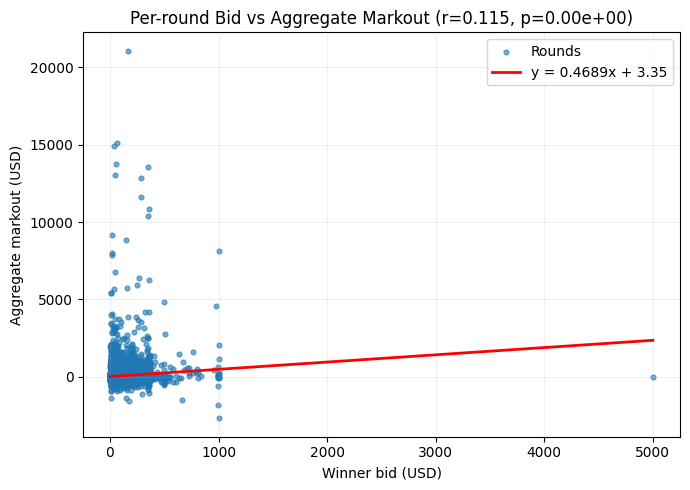

In [4]:
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

CSV_PATH = Path.cwd() / "auction_resolved_with_markouts.csv"

df = pl.read_csv(CSV_PATH)
# Expect columns: bid_in_usd, agg_markout
if not {"bid_in_usd", "agg_markout"}.issubset(set(df.columns)):
	raise ValueError("CSV missing required columns: bid_in_usd, agg_markout")

df = df.select([
	pl.col("bid_in_usd").cast(pl.Float64).alias("x"),
	pl.col("agg_markout").cast(pl.Float64).alias("y"),
]).drop_nulls()

x = df["x"].to_numpy()
y = df["y"].to_numpy()

# Pearson correlation and p-value
r, p = stats.pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p-value = {p:.3e}")

# Simple linear regression using numpy polyfit
coef = np.polyfit(x, y, deg=1)
lin = np.poly1d(coef)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=12, alpha=0.6, label="Rounds")
# Regression line across x-range
x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, lin(x_line), color="red", linewidth=2, label=f"y = {coef[0]:.4f}x + {coef[1]:.2f}")
plt.xlabel("Winner bid (USD)")
plt.ylabel("Aggregate markout (USD)")
plt.title(f"Per-round Bid vs Aggregate Markout (r={r:.3f}, p={p:.2e})")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


Top bidders:
shape: (3, 2)
┌─────────────────────────────────┬───────┐
│ first_price_bidder              ┆ wins  │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ 0x95c0d21482fd6bc204e588c06632… ┆ 66686 │
│ 0x8c6ffc5501aca218f5f60e140d2c… ┆ 56285 │
│ 0x2b38a73dd32a2eafe849825a4b51… ┆ 7636  │
└─────────────────────────────────┴───────┘


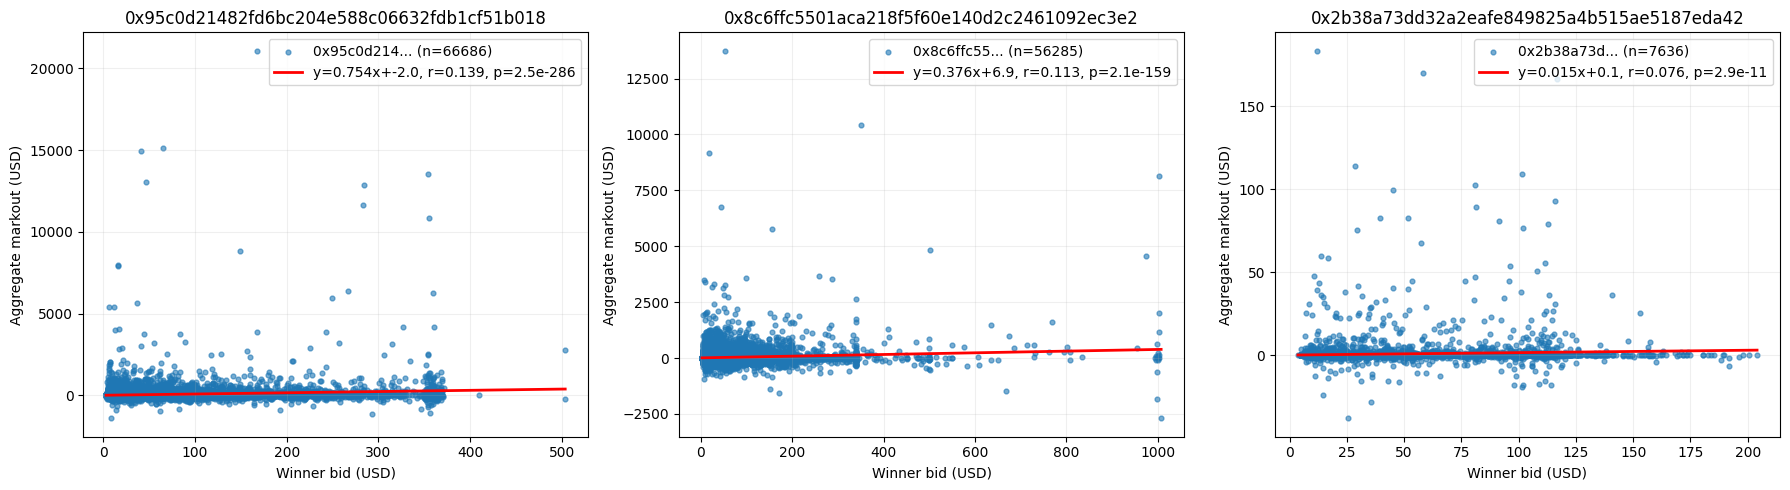

In [ ]:
# Top-3 winners: per-bidder regression
full = pl.read_csv(CSV_PATH)

required_cols = {"first_price_bidder", "bid_in_usd", "agg_markout"}
if not required_cols.issubset(set(full.columns)):
	raise ValueError(f"CSV missing required columns: {required_cols}")

# Count wins per bidder and take top 3
counts = (
	full.filter(pl.col("first_price_bidder").is_not_null())
	.group_by("first_price_bidder").agg(pl.len().alias("wins"))
	.sort("wins", descending=True)
)

top_bidders = counts.head(3)["first_price_bidder"].to_list()
print("Top bidders:")
print(counts.head(3))

n = len(top_bidders)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), squeeze=False)
axes = axes[0]

for i, addr in enumerate(top_bidders):
	sub = (
		full.filter(pl.col("first_price_bidder") == addr)
		.select([
			pl.col("bid_in_usd").cast(pl.Float64).alias("x"),
			pl.col("agg_markout").cast(pl.Float64).alias("y"),
		])
		.drop_nulls()
	)
	x = sub["x"].to_numpy()
	y = sub["y"].to_numpy()
	ax = axes[i]
	if x.size < 2:
		ax.set_title(f"{addr}\n(insufficient data)")
		ax.axis('off')
		continue

	# Stats and regression
	r, p = stats.pearsonr(x, y)
	coef = np.polyfit(x, y, deg=1)
	lin = np.poly1d(coef)

	# Plot
	ax.scatter(x, y, s=12, alpha=0.6, label=f"{addr[:10]}... (n={x.size})")
	x_line = np.linspace(x.min(), x.max(), 200)
	ax.plot(x_line, lin(x_line), color="red", linewidth=2,
			label=f"y={coef[0]:.3f}x+{coef[1]:.1f}, r={r:.3f}, p={p:.1e}")
	ax.set_xlabel("Winner bid (USD)")
	ax.set_ylabel("Aggregate markout (USD)")
	ax.set_title(addr)
	ax.grid(True, alpha=0.2)
	ax.legend()

plt.tight_layout()
plt.show()
